## EDA (Exploratory data analysis)

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
df = pd.read_csv("data/processed/laptops_cleaned.csv")

In [4]:
df.head()
df = df.drop(columns="Unnamed: 0")

In [32]:
df.shape

(614, 9)

In [34]:
df.head()

,brand,original_price,current_price,discount_price,ram,storage,os,graphics,processor
0,MICROSOFT,118498.0,111102.0,6.241456,16.0,256.0,Windows 11,Integrated,Snapdragon X
1,MICROSOFT,115898.0,110902.0,4.310687,16.0,512.0,Windows 11,Integrated,Snapdragon X
2,ASUS,48990.0,40990.0,16.329863,8.0,512.0,Windows 11,Integrated,AMD Ryzen 5
3,ASUS,50990.0,37990.0,25.495195,8.0,512.0,Windows 11,Integrated,Intel Core i3
4,HP,120928.0,112800.0,6.721355,24.0,1024.0,Windows 11,8 GB Graphics,AMD Ryzen 7


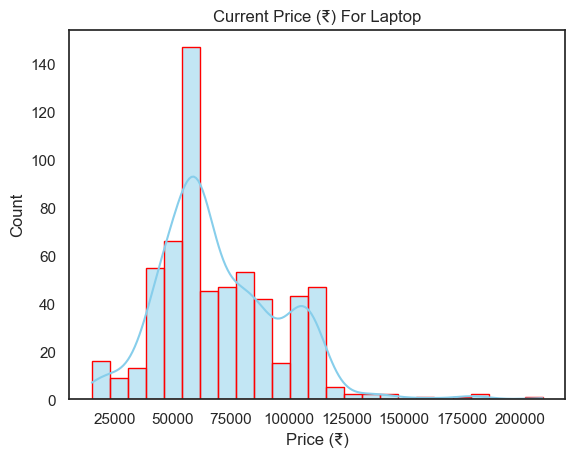

In [12]:
# Current Prices plot
sns.histplot(df['current_price'],bins = 25,color='skyblue',kde=True,edgecolor='red')
plt.xlabel('Price (₹)')
plt.ylabel('Count')
plt.title('Current Price (₹) For Laptop')
plt.show()

## Insights from the Plot
- As for the plot the values are high between 45k to 70k 
- mostly in near 60k the values are Very high


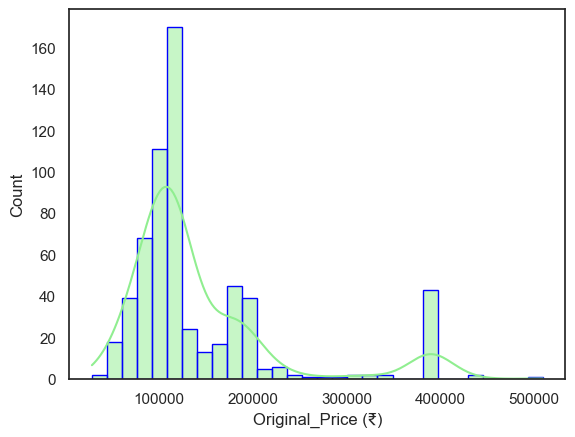

In [13]:
sns.histplot(df['original_price'],kde=True,color='lightgreen',edgecolor='blue',bins=30)
plt.xlabel('Original_Price (₹)')
plt.ylabel('Count')
plt.show()

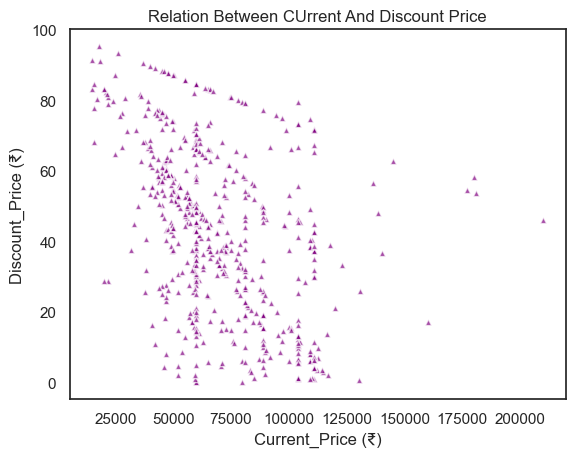

In [14]:
# Relation between CUrrent Price and Discount
sns.scatterplot(x=df['current_price'],marker="^",y=df["discount_price"],s=20,c='purple',linewidths=1,alpha=0.7)
plt.title('Relation Between CUrrent And Discount Price')
plt.xlabel('Current_Price (₹)')
plt.ylabel('Discount_Price (₹)')

plt.show()

## Insights Noticed from the chart :
- laptops below 1.2lakh get more  discount 
- Some cheap laptops also have low discounts
- Budget laptops are discounted more aggressively. Premium laptops hold their price.

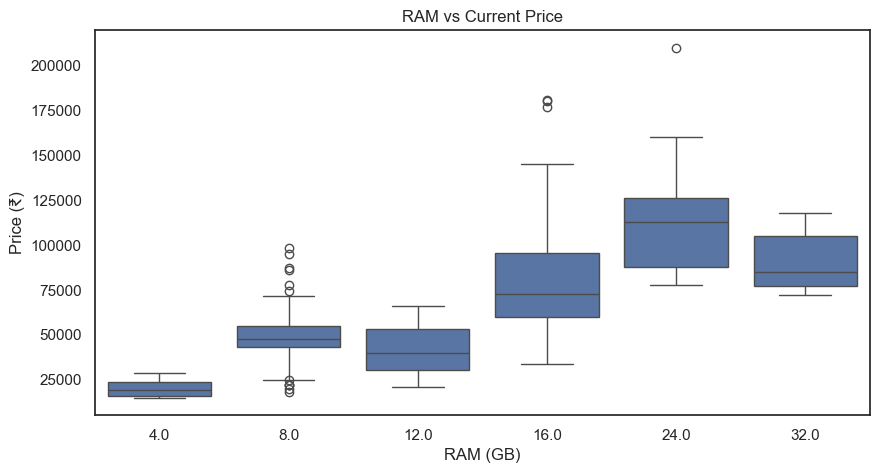

In [15]:
# Relation between Ram and current Price
plt.figure(figsize=(10,5))
sns.boxplot(x="ram", y="current_price", data=df)
plt.title("RAM vs Current Price")
plt.xlabel("RAM (GB)")
plt.ylabel("Price (₹)")
plt.show()

## Insights from the about plot:
- Higher RAM = higher price (clear pattern)
- 16GB is the most common RAM size
- 24GB outlier is Apple MacBook — legitimate premium pricing
- 4GB laptops are budget segment (under ₹30k)

In [16]:
# finding the outlier
print(df[df["ram"] == 24].sort_values("current_price", ascending=False).head(3))

     brand  original_price  current_price  discount_price   ram  storage  \
592  Apple        389990.0       209900.0       46.178107  24.0   1024.0   
100     HP        192990.0       159990.0       17.099332  24.0   1024.0   
209     HP        118498.0       114990.0        2.960388  24.0   1024.0   

             os       graphics         processor  
592  Windows 11     Integrated  Intel Core Ultra  
100  Windows 11  8 GB Graphics       AMD Ryzen 9  
209  Windows 11  8 GB Graphics      Intel Core 7  


these are outliers but they are legitmate product not data error so we are not removing the error

In [17]:
df

,brand,original_price,current_price,discount_price,ram,storage,os,graphics,processor
0,MICROSOFT,118498.0,111102.0,6.241456,16.0,256.0,Windows 11,Integrated,Snapdragon X
1,MICROSOFT,115898.0,110902.0,4.310687,16.0,512.0,Windows 11,Integrated,Snapdragon X
2,ASUS,48990.0,40990.0,16.329863,8.0,512.0,Windows 11,Integrated,AMD Ryzen 5
3,ASUS,50990.0,37990.0,25.495195,8.0,512.0,Windows 11,Integrated,Intel Core i3
4,HP,120928.0,112800.0,6.721355,24.0,1024.0,Windows 11,8 GB Graphics,AMD Ryzen 7
...,...,...,...,...,...,...,...,...,...
609,ASUS,347990.0,98991.0,71.553493,16.0,512.0,Windows 11,Integrated,Intel Core i5
610,ASUS,109999.0,88990.0,19.099265,16.0,512.0,Windows 11,Integrated,Intel Core Ultra
611,Lenovo,192990.0,84990.0,55.961449,16.0,512.0,Windows 11,Integrated,Intel Core i7
612,Lenovo,79990.0,49990.0,37.504688,16.0,512.0,Windows 11,Integrated,AMD Ryzen 5


C:\Users\91706\AppData\Local\Temp\ipykernel_920\3436583162.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.values, y=counts.index, palette="viridis")


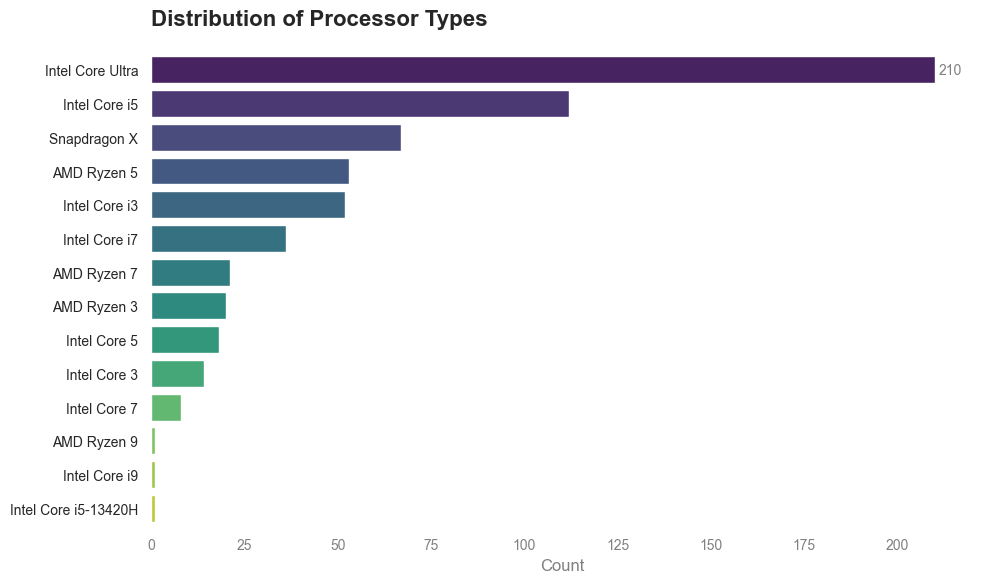

In [18]:
counts = df['processor'].value_counts()

sns.set_theme(style="white")
# 2. Create the plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=counts.values, y=counts.index, palette="viridis")

# 3. Add data labels (the "Professional" touch)
ax.bar_label(ax.containers[0], padding=3, fontsize=10, color='gray')

# 4. Clean up the "Chart Junk"
sns.despine(left=True, bottom=True)
plt.title('Distribution of Processor Types', fontsize=16, pad=20, fontweight='bold', loc='left')
plt.xlabel('Count', fontsize=12, color='gray')
plt.ylabel('') # Remove redundant label
plt.xticks(fontsize=10, color='gray')
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

## Insights from the above graph 
- High Volume: Intel Core Ultra,  Intel Core i5
- Mid Range: Snapdragon X, AMD Ryzen 5, Intel Core i3, Intel Core i7
- Low Volume: AMD Ryzen 7/3, Intel Core 5/3/7
- Niche: AMD Ryzen 9, Intel Core i9, Intel Core i5-13420H